<a href="https://colab.research.google.com/github/Nik2416/Time-Series/blob/main/Time_Series_ARIMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[*********************100%***********************]  1 of 1 completed


Amazon stock data:
Price         Close     High      Low     Open    Volume
Ticker         AMZN     AMZN     AMZN     AMZN      AMZN
Date                                                    
2015-01-02  15.4260  15.7375  15.3480  15.6290  55664000
2015-01-05  15.1095  15.4190  15.0425  15.3505  55484000
2015-01-06  14.7645  15.1500  14.6190  15.1120  70380000
2015-01-07  14.9210  15.0640  14.7665  14.8750  52806000
2015-01-08  15.0230  15.1570  14.8055  15.0160  61768000

Monthly Amazon stock data:
Date
2015-01-01    17.726500
2015-02-01    19.007999
2015-03-01    18.605000
2015-04-01    21.089001
2015-05-01    21.461500
Freq: MS, Name: AMZN, dtype: float64


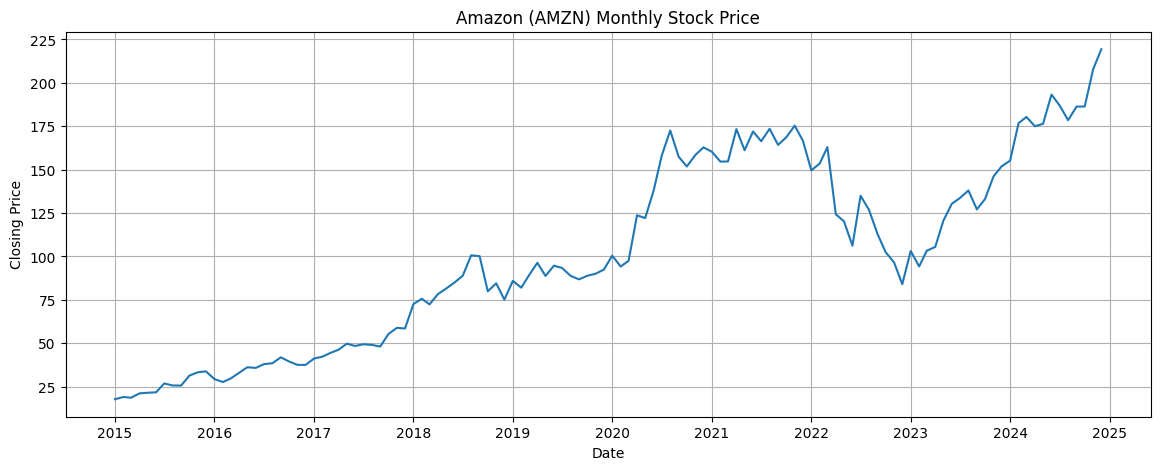

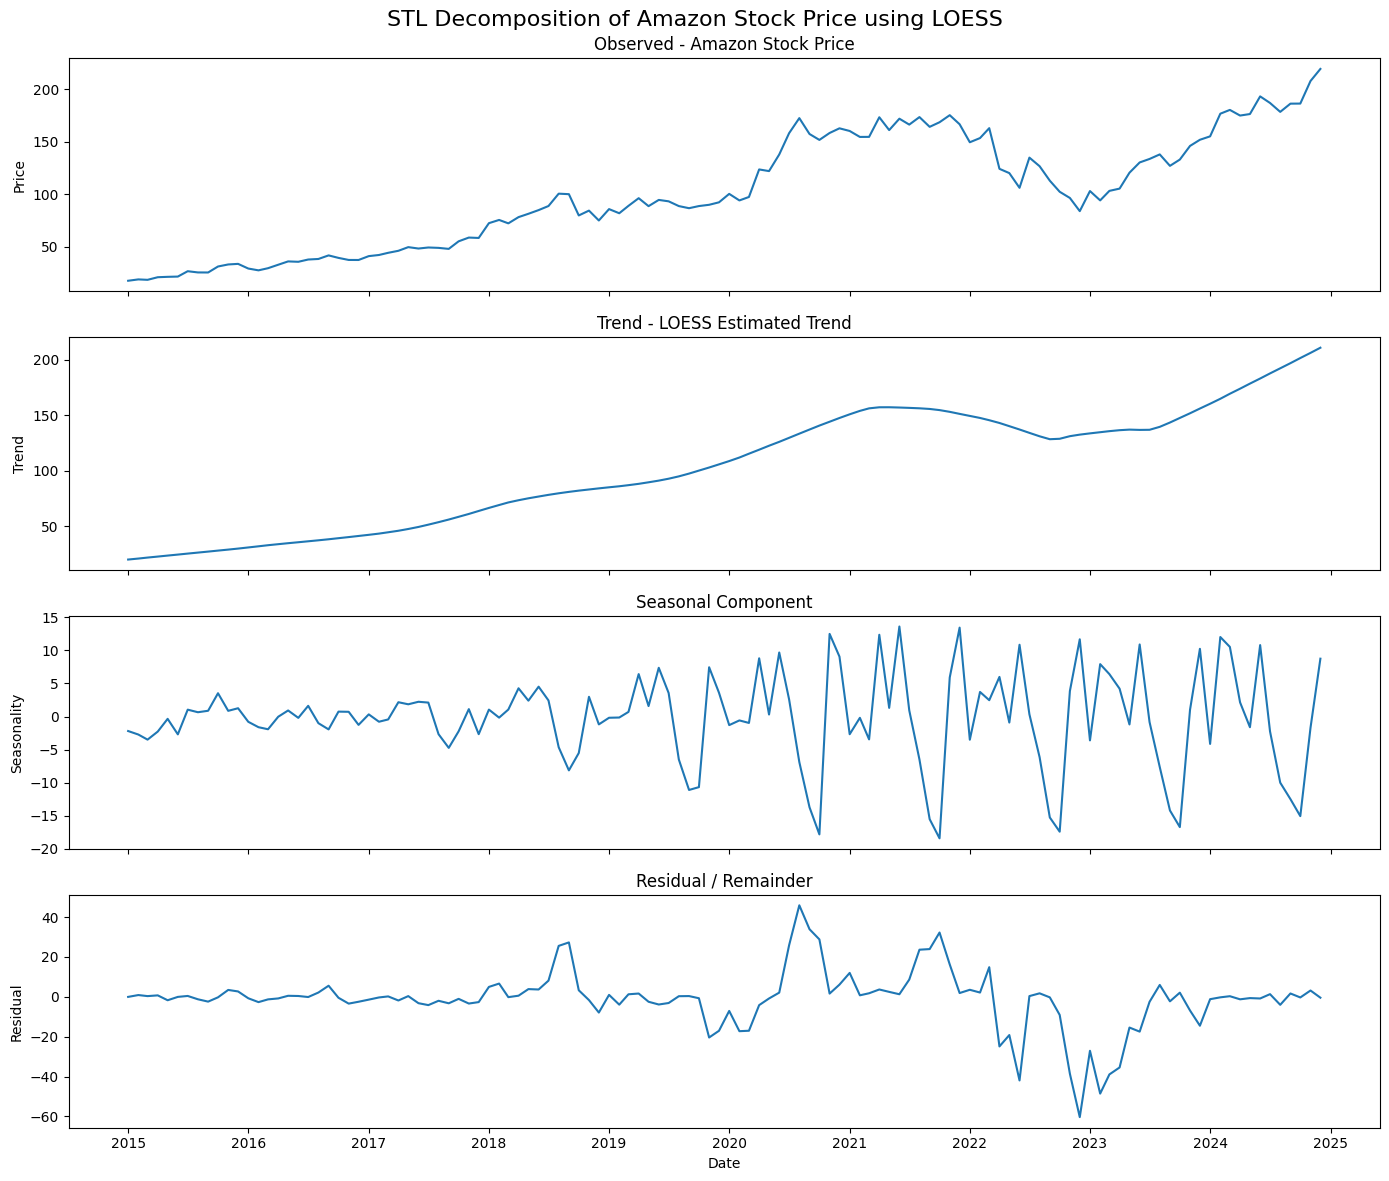


STL Decomposition Results:
             Observed      Trend  Seasonal  Residual
Date                                                
2015-01-01  17.726500  19.946240 -2.190968 -0.028772
2015-02-01  19.007999  20.836859 -2.720221  0.891361
2015-03-01  18.605000  21.730589 -3.490691  0.365102
2015-04-01  21.089001  22.627130 -2.271632  0.733503
2015-05-01  21.461500  23.525706 -0.348198 -1.716008
2015-06-01  21.704500  24.425151 -2.694372 -0.026278
2015-07-01  26.807501  25.324754  1.040154  0.442593
2015-08-01  25.644501  26.223897  0.650627 -1.230024
2015-09-01  25.594500  27.121769  0.873542 -2.400812
2015-10-01  31.295000  28.018463  3.523412 -0.246874
2015-11-01  33.240002  28.918382  0.861628  3.459992
2015-12-01  33.794498  29.841770  1.255802  2.696926
2016-01-01  29.350000  30.864431 -0.795869 -0.718561
2016-02-01  27.625999  31.889932 -1.610909 -2.653024
2016-03-01  29.681999  32.877402 -1.921245 -1.274158

STL decomposition completed successfully!
File saved as: Amazon_STL_De

In [ ]:
# ============================================================
# STL DECOMPOSITION USING LOESS - AMAZON (AMZN)
# ============================================================

# Install required libraries
!pip install yfinance statsmodels -q


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL


# ============================================================
# 2. DOWNLOAD AMAZON STOCK DATA
# ============================================================

amazon = yf.download(
    "AMZN",
    start="2015-01-01",
    end="2025-01-01",
    auto_adjust=True
)

print("Amazon stock data:")
print(amazon.head())


# ============================================================
# 3. SELECT CLOSING PRICE
# ============================================================

data = amazon["Close"]

# Handle newer yfinance MultiIndex format
if isinstance(data, pd.DataFrame):
    data = data["AMZN"]

data = data.dropna()


# ============================================================
# 4. CONVERT DAILY DATA TO MONTHLY DATA
# ============================================================

# Take the last closing price of every month
monthly_data = data.resample("MS").last()

monthly_data = monthly_data.dropna()


print("\nMonthly Amazon stock data:")
print(monthly_data.head())


# ============================================================
# 5. PLOT ORIGINAL AMAZON STOCK PRICE
# ============================================================

plt.figure(figsize=(14, 5))

plt.plot(
    monthly_data.index,
    monthly_data.values
)

plt.title("Amazon (AMZN) Monthly Stock Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.grid(True)
plt.show()


# ============================================================
# 6. STL DECOMPOSITION USING LOESS
# ============================================================

stl = STL(
    monthly_data,
    period=12,
    robust=True
)

result = stl.fit()


# ============================================================
# 7. EXTRACT COMPONENTS
# ============================================================

trend = result.trend
seasonal = result.seasonal
residual = result.resid


# ============================================================
# 8. CREATE DECOMPOSITION DATAFRAME
# ============================================================

decomposition = pd.DataFrame({
    "Observed": monthly_data,
    "Trend": trend,
    "Seasonal": seasonal,
    "Residual": residual
})


# ============================================================
# 9. DISPLAY STL DECOMPOSITION
# ============================================================

fig, axes = plt.subplots(
    4,
    1,
    figsize=(14, 12),
    sharex=True
)


# -------------------------
# Observed
# -------------------------

axes[0].plot(
    decomposition.index,
    decomposition["Observed"]
)

axes[0].set_title(
    "Observed - Amazon Stock Price"
)

axes[0].set_ylabel("Price")


# -------------------------
# Trend
# -------------------------

axes[1].plot(
    decomposition.index,
    decomposition["Trend"]
)

axes[1].set_title(
    "Trend - LOESS Estimated Trend"
)

axes[1].set_ylabel("Trend")


# -------------------------
# Seasonal
# -------------------------

axes[2].plot(
    decomposition.index,
    decomposition["Seasonal"]
)

axes[2].set_title(
    "Seasonal Component"
)

axes[2].set_ylabel("Seasonality")


# -------------------------
# Residual
# -------------------------

axes[3].plot(
    decomposition.index,
    decomposition["Residual"]
)

axes[3].set_title(
    "Residual / Remainder"
)

axes[3].set_ylabel("Residual")
axes[3].set_xlabel("Date")


# ============================================================
# 10. DISPLAY THE PLOT
# ============================================================

plt.suptitle(
    "STL Decomposition of Amazon Stock Price using LOESS",
    fontsize=16
)

plt.tight_layout()
plt.show()


# ============================================================
# 11. DISPLAY DECOMPOSITION DATA
# ============================================================

print("\nSTL Decomposition Results:")
print(decomposition.head(15))


# ============================================================
# 12. SAVE RESULTS TO CSV
# ============================================================

decomposition.to_csv(
    "Amazon_STL_Decomposition.csv"
)

print("\n========================================")
print("STL decomposition completed successfully!")
print("========================================")
print("File saved as: Amazon_STL_Decomposition.csv")